# Importing Libraries ##

In [396]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")




# Loading Dataset

In [397]:
df=pd.read_csv("NSEI_Featured.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Return_1d,Return_3d,Return_5d,Return_10d,...,MACD_Positive,BB_Upper,BB_Lower,BB_Width,BB_Position,High_Low_Ratio,Open_Close,Range,ROC_5,ROC_20
0,2013-01-28 00:00:00+05:30,6082.100098,6088.399902,6061.399902,6074.799805,113100,0.002468,0.338602,-0.123309,0.842457,...,0,6109.981930,5924.573002,0.015406,0.810246,1.004454,1.001202,0.004445,-0.123309,2.817194
1,2013-01-29 00:00:00+05:30,6064.700195,6111.799805,6042.450195,6049.899902,157600,-0.409888,0.507527,0.023145,-0.110626,...,0,6101.642332,5947.392580,0.012802,0.664554,1.011477,1.002446,0.011463,0.023145,2.452114
2,2013-01-30 00:00:00+05:30,6065.000000,6071.950195,6044.149902,6055.750000,124200,0.096697,-0.311127,0.023953,0.898055,...,0,6104.497311,5950.787601,0.012750,0.682861,1.004600,1.001527,0.004591,0.023953,1.042840
3,2013-01-31 00:00:00+05:30,6045.649902,6058.049805,6025.149902,6034.750000,168500,-0.346778,-0.659278,0.255840,-0.073688,...,0,6105.333343,5952.476569,0.012677,0.538239,1.005460,1.001806,0.005452,0.255840,0.420168
4,2013-02-01 00:00:00+05:30,6040.950195,6052.950195,5983.200195,5998.899902,159300,-0.594061,-0.842989,-1.246985,-1.080074,...,0,6105.459849,5950.625063,0.012843,0.311783,1.011658,1.007010,0.011627,-1.246985,-0.286728


# removing the features which leaks the data and splitiing dataset

In [398]:
df=df.drop(["Date"],axis=1)

In [399]:
X=df.drop(["Target_Direction"],axis=1)
y=df["Target_Direction"]

In [400]:
# 1. remove leaks
X = X.drop(["Return_3d_Future", "Return_5d_Future", 
                    "Target_Strong", "Target_Magnitude"],axis=1)

# 2. shift
X = X.shift(1)
X = X.dropna()
y = y.loc[X.index]

# 3. split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [401]:
# data is being leaked becasue of return_3d and return_5d,its leaking future info to model
# df=df.drop(['Return_3d_Future', 'Return_5d_Future'],axis=1)

# scaling dataset for distance based models

In [402]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# List of Models Being used

In [403]:


# ======================
# Models
# ======================
log_reg= LogisticRegression(max_iter=1000)
    
Ran_Forest =RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42
    )

Grad_Boosting=GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
# Svm
from sklearn.svm import SVC
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True  # IMPORTANT for predict_proba
)





# Fitting models


## Fitting Logistic Regression

In [404]:
log_reg.fit(X_train_scaled, y_train)
y_pred_lr=log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Logistic Regression accuracy on training data",accuracy_score(y_train,log_reg.predict(X_train_scaled)))
probs_lr = log_reg.predict_proba(X_test_scaled)[:,1]
print(probs_lr[:10])
print("Logistic Regression Mean Prob:", np.mean(probs_lr))




Logistic Regression Accuracy: 0.5357142857142857
Logistic Regression accuracy on training data 0.6138306138306139
[0.55337034 0.65731355 0.66044044 0.62513829 0.77643938 0.64327666
 0.66720608 0.61665183 0.61797211 0.55230509]
Logistic Regression Mean Prob: 0.6319963679763434


## Fitting Random_Forest

In [405]:
Ran_Forest.fit(X_train_scaled, y_train)
y_pred_rf=Ran_Forest.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Random Forest accuracy on training data",accuracy_score(y_train,Ran_Forest.predict(X_train_scaled)))
probs_rf = Ran_Forest.predict_proba(X_test)[:,1]
print(probs_rf[:10])
print("Random Forest Mean Prob:", np.mean(probs_rf))


Random Forest Accuracy: 0.515527950310559
Random Forest accuracy on training data 0.6247086247086248
[0.46903576 0.44216214 0.44725803 0.44759514 0.457088   0.42865651
 0.42882847 0.42211688 0.42846007 0.45186814]
Random Forest Mean Prob: 0.43303207074577627


## Fitiing Gradient Boosting

In [406]:
Grad_Boosting.fit(X_train_scaled, y_train)
y_pred_gb=Grad_Boosting.predict(X_test_scaled)
print("Gradient Boosting Accuracy:", accuracy_score(y_test,y_pred_gb))
print("Gradient Boosting accuracy on training data",accuracy_score(y_train,Grad_Boosting.predict(X_train_scaled)))
probs_gb = Grad_Boosting.predict_proba(X_test)[:,1]
print(probs_gb[:10])    
print("Gradient Boosting Mean Prob:", np.mean(probs_gb))


Gradient Boosting Accuracy: 0.5388198757763976
Gradient Boosting accuracy on training data 0.8127428127428128
[0.16597511 0.19069388 0.23381946 0.22381175 0.20937903 0.28359969
 0.27390314 0.52595662 0.65335096 0.78539474]
Gradient Boosting Mean Prob: 0.3990339307229516


## Fitting KNN

In [407]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=15,   # start here
    weights='distance'  # better than uniform
)

knn.fit(X_train_scaled, y_train)
probs_knn = knn.predict_proba(X_test_scaled)[:, 1]

print("KNN probs:", probs_knn[:10])
print("KNN mean prob:", probs_knn.mean())
threshold_knn = 0.52

y_pred_knn = (probs_knn > threshold_knn).astype(int)

print("KNN accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN precision:", precision_score(y_test, y_pred_knn))
print("KNN recall:", recall_score(y_test, y_pred_knn))

KNN probs: [0.41092047 0.34441531 0.39169781 0.38997131 0.41195341 0.58796923
 0.52912726 0.65320678 0.65416905 0.60211606]
KNN mean prob: 0.4565881862758166
KNN accuracy: 0.4922360248447205
KNN precision: 0.5644444444444444
KNN recall: 0.35674157303370785


## Tunned KNN

In [408]:
knn_tuned_v1=KNeighborsClassifier(
    n_neighbors=25,
    weights='distance'
)
knn_tuned_v1.fit(X_train_scaled, y_train)
probs_knn_v1 = knn_tuned_v1.predict_proba(X_test_scaled)[:, 1]
print("KNN probs:", probs_knn_v1[:10])
print("KNN mean prob:", probs_knn_v1.mean())
threshold_knn = 0.52

y_pred_knn = (probs_knn_v1 > threshold_knn).astype(int)

print("KNN accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN precision:", precision_score(y_test, y_pred_knn))
print("KNN recall:", recall_score(y_test, y_pred_knn))

KNN probs: [0.44633307 0.30150316 0.3230193  0.32049703 0.51999556 0.55660618
 0.51982914 0.51872199 0.67153188 0.4893846 ]
KNN mean prob: 0.47672869366935167
KNN accuracy: 0.4860248447204969
KNN precision: 0.5621890547263682
KNN recall: 0.31741573033707865


## Tunned KNN

In [409]:
knn_tuned_v2=KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn_tuned_v2.fit(X_train_scaled, y_train)
probs_knn_v2 = knn_tuned_v2.predict_proba(X_test_scaled)[:, 1]
print("KNN probs:", probs_knn_v2[:10])
print("KNN mean prob:", probs_knn_v2.mean())
threshold_knn = 0.52

y_pred_knn = (probs_knn_v2 > threshold_knn).astype(int)

print("KNN accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN precision:", precision_score(y_test, y_pred_knn))
print("KNN recall:", recall_score(y_test, y_pred_knn))

KNN probs: [0.42850928 0.29930482 0.3698405  0.3657495  0.60906244 0.19257153
 0.39556684 0.38938115 0.39173477 0.78086119]
KNN mean prob: 0.4347144414710451
KNN accuracy: 0.4704968944099379
KNN precision: 0.5303643724696356
KNN recall: 0.36797752808988765


## Fitting XGBoost

In [410]:
xgb.fit(X_train_scaled, y_train)
probs_xgb = xgb.predict_proba(X_test)[:,1]

threshold_xgb = 0.3
y_pred_xgb = (probs_xgb > threshold_xgb).astype(int)

print("XGB probs:", probs_xgb[:10])
print("XGB mean prob:", probs_xgb.mean())

print("XGB accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB precision:", precision_score(y_test, y_pred_xgb))
print("XGB recall:", recall_score(y_test, y_pred_xgb))

XGB probs: [0.32944882 0.3570783  0.24718487 0.26390818 0.26102123 0.2764605
 0.28033483 0.33716252 0.36339352 0.4826011 ]
XGB mean prob: 0.29820156
XGB accuracy: 0.4984472049689441
XGB precision: 0.5587188612099644
XGB recall: 0.4410112359550562


## Fitting SVM

In [411]:

svm.fit(X_train_scaled, y_train)
probs_svm = svm.predict_proba(X_test_scaled)[:,1]

threshold_svm = 0.52
y_pred_svm = (probs_svm > threshold_svm).astype(int)

print("SVM probs:", probs_svm[:10])
print("SVM mean prob:", probs_svm.mean())

print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM precision:", precision_score(y_test, y_pred_svm))
print("SVM recall:", recall_score(y_test, y_pred_svm))

SVM probs: [0.4658415  0.31924765 0.39982199 0.38974711 0.61952808 0.54822655
 0.55082681 0.55249972 0.60576601 0.62137707]
SVM mean prob: 0.4030772408489418
SVM accuracy: 0.47360248447204967
SVM precision: 0.6231884057971014
SVM recall: 0.12078651685393259


# Tuning Models Using GridSearchCv

## Tuning Logistic Regression

In [412]:
# lr
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression

tscv = TimeSeriesSplit(n_splits=5)

param_lr = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best LR:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

Best LR: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


## Tuning RandomForestClassidier

In [413]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

Best RF: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


## tuning GradientBoostingClassifier

In [414]:
from sklearn.ensemble import GradientBoostingClassifier

param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("Best GB:", grid_gb.best_params_)
best_gb = grid_gb.best_estimator_

Best GB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


## Tuning KNN

In [415]:
from sklearn.neighbors import KNeighborsClassifier

param_knn = {
    "n_neighbors": [5, 10, 15, 25],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best KNN:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_

Best KNN: {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'uniform'}


## tuning GridSearchCV

In [416]:
from sklearn.model_selection import GridSearchCV

param_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    param_xgb,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB:", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_

Best XGB: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


## tuning SVM

In [417]:
# svm tuned
param_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_svm,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best SVM:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

Best SVM: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


# Comparing scores of Tuned Vs Untuned Models

## Logistic Regression

In [418]:
# Untuned
probs_lr = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred_lr = (probs_lr > 0.5).astype(int)

print("\nLR - Untuned")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

# Tuned
probs_lr_t = best_lr.predict_proba(X_test_scaled)[:,1]
y_pred_lr_t = (probs_lr_t > 0.5).astype(int)

print("\nLR - Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_t))
print("Precision:", precision_score(y_test, y_pred_lr_t))
print("Recall:", recall_score(y_test, y_pred_lr_t))


LR - Untuned
Accuracy: 0.5590062111801242
Precision: 0.5620689655172414
Recall: 0.9157303370786517

LR - Tuned
Accuracy: 0.5590062111801242
Precision: 0.5620689655172414
Recall: 0.9157303370786517


## RandomForestClassifier

In [419]:
# Untuned
probs_rf = Ran_Forest.predict_proba(X_test)[:,1]
y_pred_rf = (probs_rf > 0.5).astype(int)

print("\nRF - Untuned")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

# Tuned
probs_rf_t = best_rf.predict_proba(X_test)[:,1]
y_pred_rf_t = (probs_rf_t > 0.5).astype(int)

print("\nRF - Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_t))
print("Precision:", precision_score(y_test, y_pred_rf_t))
print("Recall:", recall_score(y_test, y_pred_rf_t))


RF - Untuned
Accuracy: 0.4472049689440994
Precision: 0.0
Recall: 0.0

RF - Tuned
Accuracy: 0.5046583850931677
Precision: 0.5618729096989966
Recall: 0.47191011235955055


## GradientBoostingClassifier

In [420]:
# Untuned
probs_gb = Grad_Boosting.predict_proba(X_test)[:,1]
y_pred_gb = (probs_gb > 0.5).astype(int)

print("\nGB - Untuned")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))

# Tuned
probs_gb_t = best_gb.predict_proba(X_test)[:,1]
y_pred_gb_t = (probs_gb_t > 0.5).astype(int)

print("\nGB - Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_gb_t))
print("Precision:", precision_score(y_test, y_pred_gb_t))
print("Recall:", recall_score(y_test, y_pred_gb_t))


GB - Untuned
Accuracy: 0.44875776397515527
Precision: 0.5023041474654378
Recall: 0.3061797752808989

GB - Tuned
Accuracy: 0.5434782608695652
Precision: 0.5945121951219512
Recall: 0.547752808988764


## KNN

In [421]:
# Untuned
probs_knn = knn.predict_proba(X_test_scaled)[:,1]
y_pred_knn = (probs_knn > 0.5).astype(int)

print("\nKNN - Untuned")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))

# Tuned
probs_knn_t = best_knn.predict_proba(X_test_scaled)[:,1]
y_pred_knn_t = (probs_knn_t > 0.5).astype(int)

print("\nKNN - Tuned")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_t))
print("Precision:", precision_score(y_test, y_pred_knn_t))
print("Recall:", recall_score(y_test, y_pred_knn_t))


KNN - Untuned
Accuracy: 0.4922360248447205
Precision: 0.5638766519823789
Recall: 0.3595505617977528

KNN - Tuned
Accuracy: 0.515527950310559
Precision: 0.5683229813664596
Recall: 0.5140449438202247


## XGBoost

In [422]:
# =========================
# Untuned XGB
# =========================
probs_xgb = xgb.predict_proba(X_test)[:,1]

print("\nXGB - Untuned")
print("Mean Prob:", probs_xgb.mean())
print("Sample probs:", probs_xgb[:10])

threshold = 0.30   # SAME threshold for both

y_pred_xgb = (probs_xgb > threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))


# =========================
# Tuned XGB
# =========================
probs_xgb_t = best_xgb.predict_proba(X_test)[:,1]

print("\nXGB - Tuned")
print("Mean Prob:", probs_xgb_t.mean())
print("Sample probs:", probs_xgb_t[:10])

y_pred_xgb_t = (probs_xgb_t > threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb_t))
print("Precision:", precision_score(y_test, y_pred_xgb_t))
print("Recall   :", recall_score(y_test, y_pred_xgb_t))


XGB - Untuned
Mean Prob: 0.29820156
Sample probs: [0.32944882 0.3570783  0.24718487 0.26390818 0.26102123 0.2764605
 0.28033483 0.33716252 0.36339352 0.4826011 ]
Accuracy : 0.4984472049689441
Precision: 0.5587188612099644
Recall   : 0.4410112359550562

XGB - Tuned
Mean Prob: 0.5319354
Sample probs: [0.52580374 0.60664874 0.5267879  0.5267879  0.5745146  0.5470927
 0.55728483 0.5745146  0.5745146  0.55973417]
Accuracy : 0.5527950310559007
Precision: 0.5527950310559007
Recall   : 1.0


# Ranking All The Models

In [423]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

results = []

# =========================
# Logistic Regression
# =========================
# Untuned
probs_lr = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred_lr = (probs_lr > 0.5).astype(int)

results.append(["LR (Untuned)",
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr)
])

# Tuned
probs_lr_t = best_lr.predict_proba(X_test_scaled)[:,1]
y_pred_lr_t = (probs_lr_t > 0.5).astype(int)

results.append(["LR (Tuned)",
    accuracy_score(y_test, y_pred_lr_t),
    precision_score(y_test, y_pred_lr_t),
    recall_score(y_test, y_pred_lr_t)
])


# =========================
# Random Forest
# =========================
probs_rf = Ran_Forest.predict_proba(X_test)[:,1]
y_pred_rf = (probs_rf > 0.5).astype(int)

results.append(["RF (Untuned)",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf)
])

probs_rf_t = best_rf.predict_proba(X_test)[:,1]
y_pred_rf_t = (probs_rf_t > 0.5).astype(int)

results.append(["RF (Tuned)",
    accuracy_score(y_test, y_pred_rf_t),
    precision_score(y_test, y_pred_rf_t),
    recall_score(y_test, y_pred_rf_t)
])


# =========================
# Gradient Boosting
# =========================
probs_gb = Grad_Boosting.predict_proba(X_test)[:,1]
y_pred_gb = (probs_gb > 0.5).astype(int)

results.append(["GB (Untuned)",
    accuracy_score(y_test, y_pred_gb),
    precision_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_gb)
])

probs_gb_t = best_gb.predict_proba(X_test)[:,1]
y_pred_gb_t = (probs_gb_t > 0.5).astype(int)

results.append(["GB (Tuned)",
    accuracy_score(y_test, y_pred_gb_t),
    precision_score(y_test, y_pred_gb_t),
    recall_score(y_test, y_pred_gb_t)
])


# =========================
# KNN
# =========================
probs_knn = knn.predict_proba(X_test_scaled)[:,1]
y_pred_knn = (probs_knn > 0.5).astype(int)

results.append(["KNN (Untuned)",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn)
])

probs_knn_t = best_knn.predict_proba(X_test_scaled)[:,1]
y_pred_knn_t = (probs_knn_t > 0.5).astype(int)

results.append(["KNN (Tuned)",
    accuracy_score(y_test, y_pred_knn_t),
    precision_score(y_test, y_pred_knn_t),
    recall_score(y_test, y_pred_knn_t)
])


# =========================
# XGBoost
# =========================
# Untuned (LOW threshold!)
probs_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (probs_xgb > 0.30).astype(int)

results.append(["XGB (Untuned)",
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb)
])

# Tuned
probs_xgb_t = best_xgb.predict_proba(X_test)[:,1]
y_pred_xgb_t = (probs_xgb_t > 0.5).astype(int)

results.append(["XGB (Tuned)",
    accuracy_score(y_test, y_pred_xgb_t),
    precision_score(y_test, y_pred_xgb_t),
    recall_score(y_test, y_pred_xgb_t)
])


# =========================
# SVM
# =========================
probs_svm = svm.predict_proba(X_test_scaled)[:,1]
y_pred_svm = (probs_svm > 0.5).astype(int)

results.append(["SVM (Untuned)",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm)
])

probs_svm_t = best_svm.predict_proba(X_test_scaled)[:,1]
y_pred_svm_t = (probs_svm_t > 0.5).astype(int)

results.append(["SVM (Tuned)",
    accuracy_score(y_test, y_pred_svm_t),
    precision_score(y_test, y_pred_svm_t),
    recall_score(y_test, y_pred_svm_t)
])


# =========================
# Create ranking table
# =========================
df_results = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall"]
)

# Sort by Precision (important for your use case)
df_results = df_results.sort_values(by="Precision", ascending=False)

print(df_results)

            Model  Accuracy  Precision    Recall
11    SVM (Tuned)  0.571429   0.617647  0.589888
10  SVM (Untuned)  0.475155   0.604651  0.146067
5      GB (Tuned)  0.543478   0.594512  0.547753
9     XGB (Tuned)  0.566770   0.572233  0.856742
7     KNN (Tuned)  0.515528   0.568323  0.514045
6   KNN (Untuned)  0.492236   0.563877  0.359551
0    LR (Untuned)  0.559006   0.562069  0.915730
1      LR (Tuned)  0.559006   0.562069  0.915730
3      RF (Tuned)  0.504658   0.561873  0.471910
8   XGB (Untuned)  0.498447   0.558719  0.441011
4    GB (Untuned)  0.448758   0.502304  0.306180
2    RF (Untuned)  0.447205   0.000000  0.000000


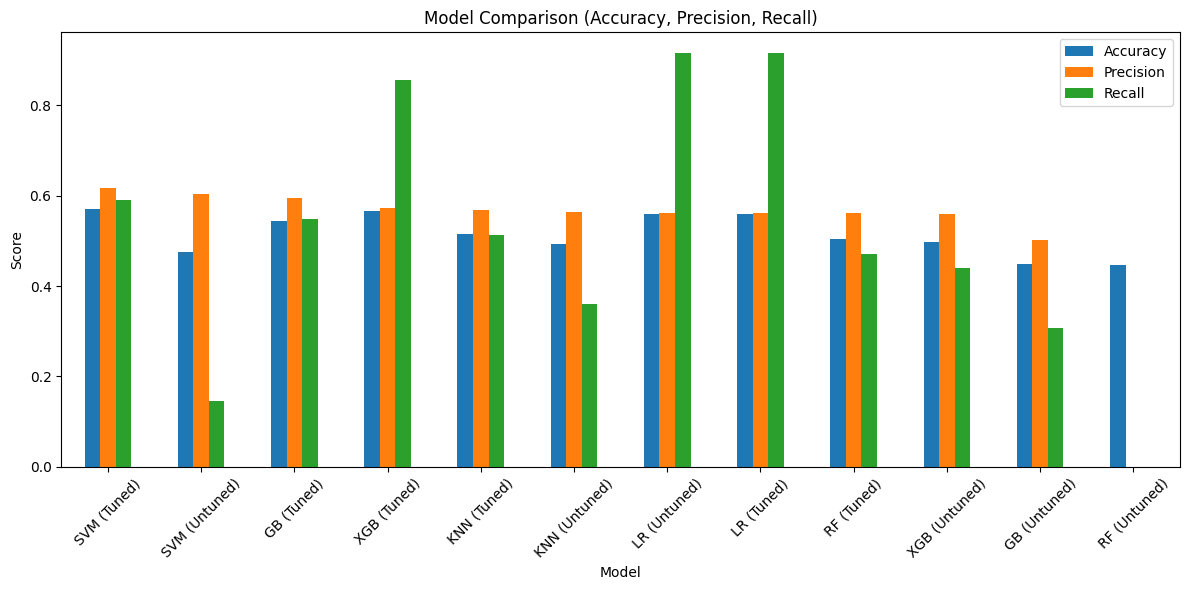

In [424]:
import matplotlib.pyplot as plt

# Assuming df_results already exists
# (Model, Accuracy, Precision, Recall)

df = df_results.set_index("Model")

df.plot(kind="bar", figsize=(12,6))

plt.title("Model Comparison (Accuracy, Precision, Recall)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="best")

plt.tight_layout()
plt.show()

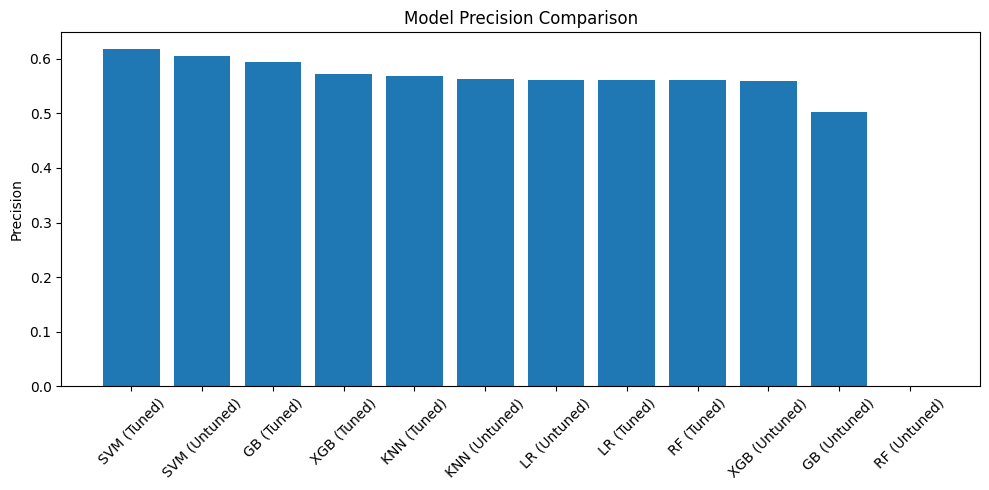

In [425]:
df_sorted = df_results.sort_values(by="Precision", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_sorted["Model"], df_sorted["Precision"])

plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

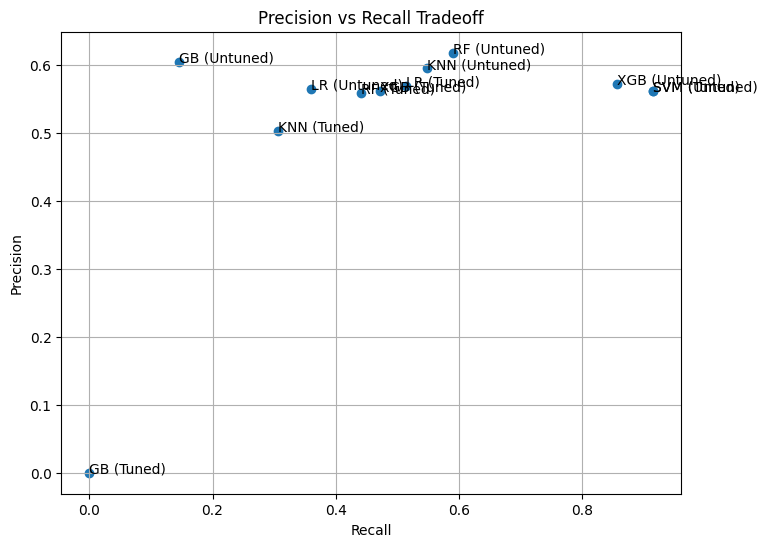

In [426]:
plt.figure(figsize=(8,6))

plt.scatter(df_results["Recall"], df_results["Precision"])

for i, model in enumerate(df_results["Model"]):
    plt.text(df_results["Recall"][i], df_results["Precision"][i], model)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Tradeoff")

plt.grid()
plt.show()

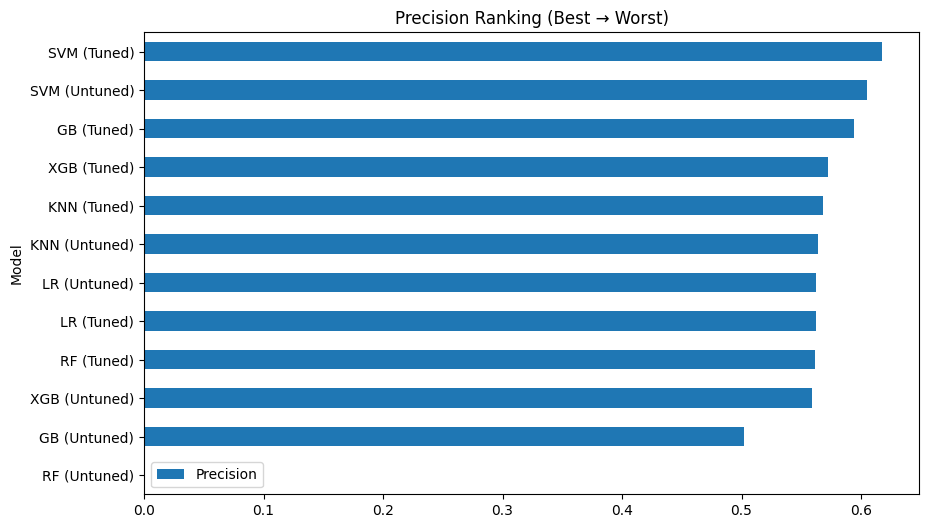

In [427]:
df_sorted.plot(kind="barh", x="Model", y="Precision", figsize=(10,6))
plt.title("Precision Ranking (Best → Worst)")
plt.gca().invert_yaxis()
plt.show()